In [23]:
%pylab inline
%load_ext autoreload
%autoreload 2

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# Read the mhd file from data
from gecco.utils import write_run_all_script, write_python_script_pelvis
import os

import mpl_interactions as pli
from gecco import patient_data
import gecco as fc
import numpy as np
from gecco.utils import nrrd_to_mhd, cropping_tool

# General Instructions

## 1) Save dicom to Nrrd file

Open slicer => load dicom data => export as nrrd

(Look into slicer documentation for help with this)
Nrrd is the default export type

## 2) Dataset generation instructions

### 2.1) Open Notebook 1-Write_pytho_sim_script.ipynb

Change fmx_path to point at your FastMC executable file.

Change the path to point to the nrrd files you want to load
One line for each file in the nrrd_files dictionary object

## 2.2) Change the orientation

We need to find the dimensional transposition that maps the axes such that the first dimension is axial
Otherwise the CBCT will not rotate around the right dimension

To do this: Run the cells up to the "Plot one slice: Make sure it is axial" cell. If this shows an axial plot
keep the orientation in the second variable in the nrrd_files dictionary (e.g. `[1,0,2]`) otherwise change the mapping
to a different one (e.g. `[2,1,0]`), repeat running the cells between the dictionary initialization and the plotting
until it is axial.

## 2.3) Crop the arrays

After finding the orientation for all files run the cropping cell for each nrrd file,

**! Only after finding the orientation, if you have the wrong orientation the crop will be wrong.**

Use the GUI to crop the file. Make sure your image isocenter is at the center of the image.
There isn't another way to shift the field of view of the image! So make sure it is aligned
If there is too much air on one side of the image, the isocenter will be shifted and the patient
might be outside the field of view of the CBCT.

=> This tells GECCO to save the phantom with a crop
=> Important for centering the projections

Repeat this process for all files

## 2.4) Run a test run

Complete all cells including the files under "Write all the files this is into a test directory"

This writes runs with only 1e6 primaries to a directory for testing.

When this is completed open a terminal and run the command `./run_all.sh` in the test_python_scripts directory

There should be green GGEMS simulations showing up in the output and Done - Completed without errors with
GECCO finding and loading the projections, something like:

```
[2024-06-04 09:56:47,260] {patient_data.py:258} INFO - ggems files loaded
[2024-06-04 09:56:47,260] {patient_data.py:259} INFO -     Scatter files:
[2024-06-04 09:56:47,260] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_0.00-scatter.mhd
[2024-06-04 09:56:47,260] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,260] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_108.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,261] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_144.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,261] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_180.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,261] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_216.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,261] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_252.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,261] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_288.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,261] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_324.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,261] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_36.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)
[2024-06-04 09:56:47,261] {patient_data.py:262} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/fastmc_output_7/fastmc_72.00-scatter.mhd
[2024-06-04 09:56:47,261] {patient_data.py:264} INFO -           Shape:(360, 360)

Done - Completed without errors
```

If this is not the case GECCO is not finding the simulation files, look in the output of the function for clues
as to why this might be.

## 2.5) Run the full simulation

If the test completes and find the files then complete the rest of the notebook

Then go into the python_scripts directory and run `./run_all.sh` to start the 1e10 primary photon simulations.



Read the nrrd_file

In [37]:
# Number : [path, orientation, crop]
fmc_path = '/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/FastMC'

nrrd_files = {'0':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd',[1,0,2],[313,511,111,367,None,None]],
            '1':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd',[1,0,2],[200,300,111,367,None,None]],
            '2':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd',[1,0,2],[287,511,2,392,15,78]],
            '3':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd',[1,0,2],[254,None,None,None,None,None]],
            '4':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd',[2,1,0],[None,114,None,None,None,None]],
            '5':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd',[2,1,0],[None,72,None,None,None,None]],
            '6':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd',[2,1,0],[None,70,None,None,None,None]],
            '7':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd',[1,0,2],[367,None,None,None,None,None]]}


In [38]:
file_index = '2' # File index to load

Crop the nrrd file

In [39]:
cropping_tool(nrrd_file=nrrd_files[file_index][0],tr=nrrd_files[file_index][1]) # Center on center of bladder
tr = nrrd_files[file_index][1]
crop = nrrd_files[file_index][2]

interactive(children=(IntSlider(value=0, description='x_start', max=511), IntSlider(value=511, description='x_…

Write to mhd

In [35]:
nrrd_to_mhd(nrrd_files[file_index][0],force=True,tr=tr,crop=crop) # crop=[-200,None,None,None,None,None]

[2025-01-27 14:50:15,560] {utils.py:676} INFO - Directory /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Female_Patient_2 already exists, but is being overwriten
[2025-01-27 14:50:15,562] {utils.py:681} INFO - Creating directory Pelvis_Female_Patient_2


[2025-01-27 14:50:16,743] {utils.py:774} INFO - Transposing the data
[2025-01-27 14:50:16,744] {utils.py:776} INFO - The spacing is [1.318359 1.318359 2.5     ]
[2025-01-27 14:50:16,745] {utils.py:778} INFO - The origin is [-329.519531  231.206635   40.      ]
[2025-01-27 14:50:16,745] {utils.py:779} INFO - The shape is (512, 512, 182)
[2025-01-27 14:50:16,770] {utils.py:747} INFO -     Processing HU section 0
[2025-01-27 14:50:16,796] {utils.py:747} INFO -     Processing HU section 1
[2025-01-27 14:50:16,820] {utils.py:747} INFO -     Processing HU section 2
[2025-01-27 14:50:16,836] {utils.py:747} INFO -     Processing HU section 3
[2025-01-27 14:50:16,848] {utils.py:747} INFO -     Processing HU section 4
[2025-01-27 14:50:16,861] {utils.py:747} INFO -     Processing HU section 5
[2025-01-27 14:50:16,875] {utils.py:747} INFO -     Processing HU section 6
[2025-01-27 14:50:16,887] {utils.py:747} INFO -     Processing HU section 7
[2025-01-27 14:50:16,901] {utils.py:747} INFO -     Pr

Sample the phantom

In [36]:
phantom = patient_data.patient_phantom(nrrd_files[file_index][0], 1e6, force_materials=True, is_fullfan=False) #, reload=True, sim_num = 14)

[2025-01-27 14:50:19,478] {utils.py:186} INFO - Using default geometry, DSD = 1510, nDetector = [512, 512], dDetector = [0.784, 0.784]
[2025-01-27 14:50:19,479] {utils.py:496} INFO - Loading density data from file
[2025-01-27 14:50:19,480] {utils.py:552} INFO - Loading attenuation files from /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Female_Patient_2/Pelvis_Female_Patient_2_materials.txt
[2025-01-27 14:50:19,481] {utils.py:553} INFO - Making attenuation files in gecco:
[2025-01-27 14:50:19,483] {utils.py:594} INFO -     Saved Air atten to file in data/mu/Air.csv
[2025-01-27 14:50:19,486] {utils.py:594} INFO -     Saved polyurethane atten to file in data/mu/polyurethane.csv
[2025-01-27 14:50:19,487] {utils.py:594} INFO -     Saved teflon atten to file in data/mu/teflon.csv
[2025-01-27 14:50:19,488] {utils.py:594} INFO -     Saved pmp atten to file in data/mu/pmp.csv
[2025-01-27 14:50:19,491] {utils.py:594} INFO -     Saved bone50 atten to file in data/mu/bone50.csv
[20

Plot one slice: Make sure it is axial

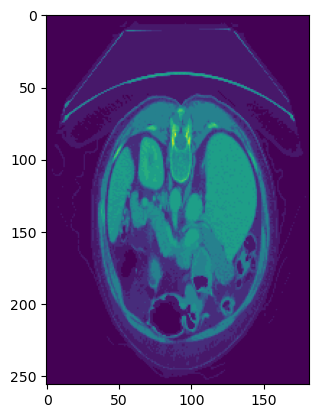

In [30]:
plt.figure()
plt.imshow(phantom.phantom[30,:,:])

In [31]:
%matplotlib widget

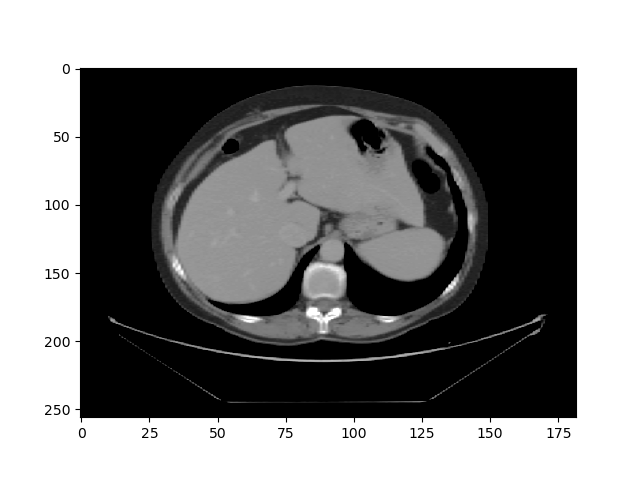

In [32]:
plt.figure()
pli.hyperslicer(np.flip(np.flip(phantom.density,axis = 1),2),cmap='gray',vmin=0.8,vmax=1.3,aspect=0.5)

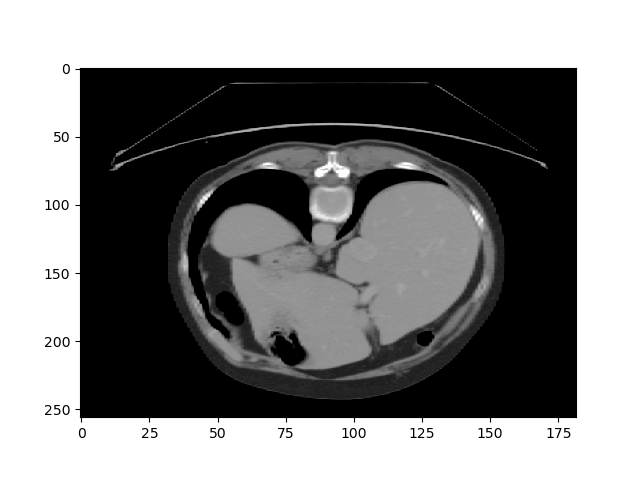

In [33]:
plt.figure()
pli.hyperslicer(phantom.density,cmap='gray',vmin=0.8,vmax=1.3,aspect=0.5)

## Write all the files

This is into a test directory

In [34]:
for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '_test.py'
    test_sim_dir = './test_python_scripts/'

    write_python_script_pelvis(nrrd[0],os.path.join(test_sim_dir,test_file_name),tr=nrrd[1],crop=nrrd[2],nphoton=1e6,fast_mc_path=fmc_path)

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),test_sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./test_python_scripts/run_all.sh

0 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2025-01-27 14:28:45,236] {utils.py:1031} INFO - Script written to run all Python files in the directory


## Write all files

This is to the run directory

In [104]:
for key, nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    file_name = nrrd[0].split('/')[-1].split('.')[0] + '.py'
    sim_dir = './python_scripts/'

    write_python_script_pelvis(nrrd[0], os.path.join(sim_dir,file_name),tr=nrrd[1],crop=nrrd[2],nphoton=1e10,fast_mc_path=fmc_path)

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./python_scripts/run_all.sh

0 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2025-01-27 12:49:22,170] {utils.py:1031} INFO - Script written to run all Python files in the directory
